# Overview

This notebook implements a Bayesian hierarchical panel model to analyze 
Life Expectancy gender gaps, replicating the PyMC model in 
`bayesian_model_py.md` using `brms`.

**Model Structure:** 
- Random intercepts by country (37 OECD countries, Turkey excluded)
- Shared slopes for 12 Gap predictors
- Panel data: ~888 observations (37 countries × 24 years)
- **Preprocessing**: Standardized predictors (mean=0, std=1, population std), centered target
- **Priors**: Normal(0,1) for predictor coefficients

**Data source:** Panel data from `process.ipynb` (CSV format)

# Setup

In [1]:
#| message: false
#| warning: false

library(tidyverse)
library(brms)
library(bayesplot)
library(loo)
library(tidybayes)
library(posterior)
library(patchwork)
library(jsonlite)

# Set theme
theme_set(theme_minimal(base_size = 12))

# Set bayesplot color scheme
color_scheme_set("brightblue")

# For reproducibility
set.seed(42)

# Use all available cores
options(mc.cores = parallel::detectCores())

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Rcpp

Loading 'brms' package (version 2.23.0). Useful instructions
can be found by typing help('brms'). A more detailed introduction
to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


The following object is masked from ‘package:stats’:

    ar


This is bayesplot version 1.15.0

- Online documentation and vignettes at mc-stan.org/bayesplot

- bayesplot theme set to bayesplot::theme_default()

   * Does _

In [2]:
# Source utility functions
source("utils.R")

# Initialize logging
log_path <- "logs/bayesian_model_r_brms.txt"
init_logging(log_path, "BAYESIAN PANEL MODEL - LIFE EXPECTANCY GENDER GAPS (R/brms)")

Logging to: logs/bayesian_model_r_brms.txt 


# Load Data

The panel dataset is created by `process.ipynb` and saved to CSV.

In [3]:
# Load panel data from CSV (created by process.ipynb)
csv_path <- "../data/panel_le.csv"

if (!file.exists(csv_path)) {
  stop("Panel data not found at ", csv_path, "\n",
       "Please run process.ipynb first to create the panel data.")
}

panel <- read_csv(csv_path, show_col_types = FALSE)

log_and_print(paste0("\n", paste0(rep("=", 80), collapse = "")))
log_and_print("PANEL DATA LOADED")
log_and_print(paste0(rep("=", 80), collapse = ""))
log_and_print("Source: %s", csv_path)
log_and_print("Shape: %d x %d", nrow(panel), ncol(panel))
log_and_print("Countries: %d", n_distinct(panel$country))
log_and_print("Years: %d-%d", min(panel$Year), max(panel$Year))
log_and_print("Missing values: %d", sum(is.na(panel)))
log_and_print(paste0(rep("=", 80), collapse = ""))


PANEL DATA LOADED 
Source: ../data/panel_le.csv 
Shape: 888 x 27 
Countries: 37 
Years: 2000-2023 
Missing values: 0 


In [4]:
glimpse(panel)

Rows: 888
Columns: 27
$ country                 <chr> "AUS", "AUS", "AUS", "AUS", "AUS", "AUS", "AUS…
$ Year                    <dbl> 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007…
$ LE_gap                  <dbl> 5.3258, 5.2164, 4.9902, 4.9644, 4.9009, 4.8024…
$ Mid_Alcohol             <dbl> 1.683177, 1.633888, 1.692577, 1.683623, 1.6654…
$ Gap_Alcohol             <dbl> 2.103379, 2.035051, 2.040075, 2.005382, 1.9226…
$ Mid_Suicide             <dbl> 13.62992, 13.24545, 12.52106, 11.87477, 11.535…
$ Gap_Suicide             <dbl> 16.00476, 15.13518, 14.07272, 13.44912, 13.224…
$ Mid_Homicide            <dbl> 1.7337785, 1.6848733, 1.5879957, 1.3851044, 1.…
$ Gap_Homicide            <dbl> 1.026409395, 1.058053696, 1.014457891, 0.99046…
$ Mid_RoadTraffic         <dbl> 10.634210, 10.228433, 9.767470, 9.220344, 8.91…
$ Gap_RoadTraffic         <dbl> 9.100231, 8.891709, 8.444396, 8.019510, 8.0333…
$ Mid_Cardiovascular      <dbl> 255.5133, 249.6689, 249.1729, 240.4196, 231.83…
$ Gap_Cardiovascul

In [5]:
# Data summary
log_and_print("Panel Data Summary:")
log_and_print("  Observations: %d", nrow(panel))
log_and_print("  Countries: %d", n_distinct(panel$country))
log_and_print("  Years: %d-%d", min(panel$Year), max(panel$Year))
log_and_print("  Missing values: %d", sum(is.na(panel)))

# Target variable summary
log_and_print("\nLife Expectancy Gap (Female - Male):")
log_and_print("  Mean: %.2f years", mean(panel$LE_gap))
log_and_print("  SD: %.2f years", sd(panel$LE_gap))
log_and_print("  Range: %.2f to %.2f years", min(panel$LE_gap), max(panel$LE_gap))

Panel Data Summary: 
  Observations: 888 
  Countries: 37 
  Years: 2000-2023 
  Missing values: 0 

Life Expectancy Gap (Female - Male): 
  Mean: 5.72 years 
  SD: 1.87 years 
  Range: 2.55 to 12.67 years 


# Exploratory Analysis

Exploratory analysis in `process.ipynb` confirmed substantial between-country heterogeneity, persistent temporal structure, and moderate correlations between several gap predictors and the outcome. These findings motivated a hierarchical model with country-level intercepts and shared slopes.

`geom_smooth()` using formula = 'y ~ x'


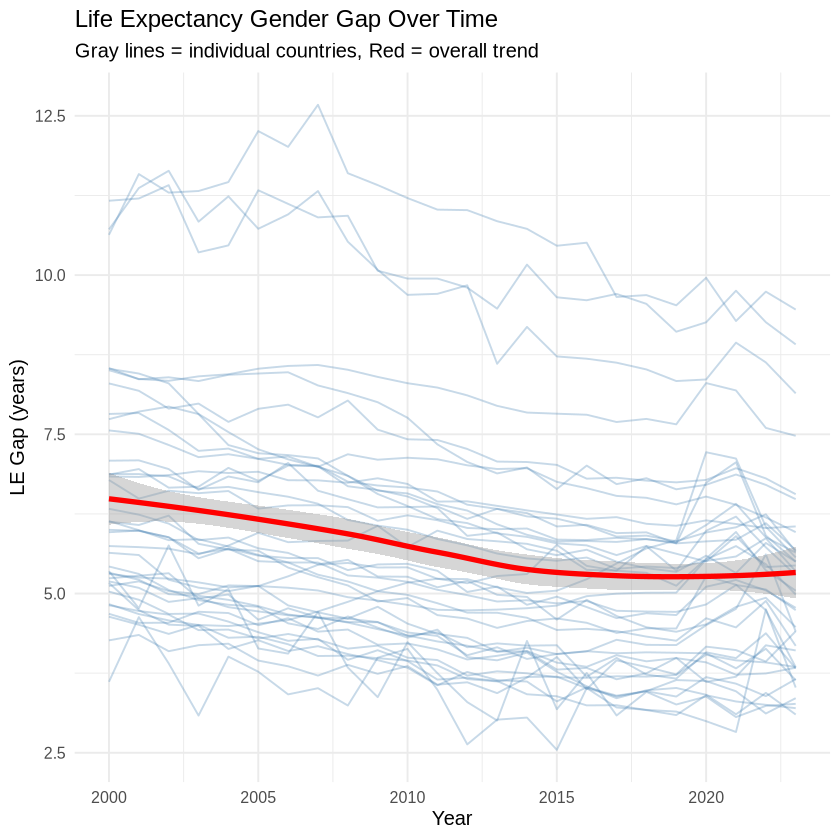

In [6]:
# Temporal trends by country
panel %>%
  ggplot(aes(x = Year, y = LE_gap, group = country)) +
  geom_line(alpha = 0.3, color = "steelblue") +
  geom_smooth(aes(group = 1), method = "loess", color = "red", linewidth = 1.5) +
  labs(
    title = "Life Expectancy Gender Gap Over Time",
    subtitle = "Gray lines = individual countries, Red = overall trend",
    x = "Year",
    y = "LE Gap (years)"
  )

# Model Specification

## Prepare Data

In [7]:
#| echo: false
# Select predictors (Gap columns only)
gap_cols <- names(panel)[str_detect(names(panel), "^Gap_")]

# Create model data frame
model_data_raw <- panel %>%
  select(LE_gap, country, Year, all_of(gap_cols)) %>%
  drop_na()

log_and_print("Raw model data: %d observations, %d predictors", 
              nrow(model_data_raw), length(gap_cols))

Raw model data: 888 observations, 12 predictors 


In [8]:
#| echo: false
# 1. Standardize predictors (mean=0, std=1, using population std ddof=0)
# 2. Center target variable (mean=0)

# Extract raw predictors and target
X_raw <- as.matrix(model_data_raw[, gap_cols])
y_raw <- model_data_raw$LE_gap

# Standardize predictors
X_mean <- colMeans(X_raw)
X_std <- apply(X_raw, 2, function(x) sqrt(mean((x - mean(x))^2)))  # Population std (ddof=0)
# Guard against zero variance columns
X_std_safe <- ifelse(X_std == 0, 1.0, X_std)
X_stdized <- sweep(sweep(X_raw, 2, X_mean, "-"), 2, X_std_safe, "/")

# Note: Target is CENTERED (mean subtracted) but NOT STANDARDIZED (no division by SD)
y_mean <- mean(y_raw)
y_centered <- y_raw - y_mean

# Create preprocessed data frame
# Replace original predictor columns with standardized versions
model_data <- model_data_raw %>%
  mutate(LE_gap_centered = y_centered)

X_stdized_df <- as.data.frame(X_stdized)
colnames(X_stdized_df) <- gap_cols  # Ensure column names match
model_data[gap_cols] <- X_stdized_df

# Verify column names are correct
log_and_print("\nVerifying standardized predictors in model_data:")
log_and_print("  Expected predictors: %s", paste(gap_cols, collapse=", "))
log_and_print("  Found in model_data: %s", paste(intersect(names(model_data), gap_cols), collapse=", "))
if (all(gap_cols %in% names(model_data))) {
  log_and_print("  ✓ All predictors found in model_data")
} else {
  log_and_print("  ✗ Missing predictors!")
}

# Store preprocessing parameters for later use, needed for feature importance
preprocessing_params <- list(
  X_mean = X_mean,
  X_std = X_std_safe,
  y_mean = y_mean,
  predictors = gap_cols
)

log_and_print("\nPreprocessing complete:")
log_and_print("  Predictors standardized: mean=0, std=1 (population std)")
log_and_print("  Target centered: mean subtracted (%.3f years)", y_mean)
log_and_print("  Standardized predictor means: [%.3f, %.3f]", 
              min(colMeans(X_stdized)), max(colMeans(X_stdized)))
log_and_print("  Standardized predictor stds: [%.3f, %.3f]", 
              min(apply(X_stdized, 2, sd)), max(apply(X_stdized, 2, sd)))
log_and_print("  Centered target mean: %.6f years", mean(y_centered))


Verifying standardized predictors in model_data: 
  Expected predictors: Gap_Alcohol, Gap_Suicide, Gap_Homicide, Gap_RoadTraffic, Gap_Cardiovascular, Gap_Diabetes, Gap_Neoplasms, Gap_ChronicRespiratory, Gap_LiverDisease, Gap_UnintentionalInjury, Gap_DrugDisorder, Gap_COVID 
  Found in model_data: Gap_Alcohol, Gap_Suicide, Gap_Homicide, Gap_RoadTraffic, Gap_Cardiovascular, Gap_Diabetes, Gap_Neoplasms, Gap_ChronicRespiratory, Gap_LiverDisease, Gap_UnintentionalInjury, Gap_DrugDisorder, Gap_COVID 
  ✓ All predictors found in model_data 

Preprocessing complete: 
  Predictors standardized: mean=0, std=1 (population std) 
  Target centered: mean subtracted (5.723 years) 
  Standardized predictor means: [-0.000, 0.000] 
  Standardized predictor stds: [1.001, 1.001] 
  Centered target mean: 0.000000 years 


In [9]:
# Summary of preprocessing (visible to reviewer)
log_and_print("\nPreprocessing summary:")
log_and_print("  Predictors: %d standardized (mean=0, std=1, population std)", length(gap_cols))
log_and_print("  Target: centered (mean subtracted: %.3f years)", y_mean)
log_and_print("  Final data: %d observations, %d countries, %d years", 
              nrow(model_data), 
              n_distinct(model_data$country),
              n_distinct(model_data$Year))


Preprocessing summary: 
  Predictors: 12 standardized (mean=0, std=1, population std) 
  Target: centered (mean subtracted: 5.723 years) 
  Final data: 888 observations, 37 countries, 24 years 


## Define Priors

In [10]:
# Priors matching PyMC model:
# - Normal(0, 1) prior for predictor coefficients (beta)
# - Normal(0, 5) prior for intercept (mu_alpha)
# - HalfNormal(1) for random effect SD (sigma_alpha)
# - HalfNormal(1) for residual SD (sigma)

model_priors <- c(
  # Normal prior for predictor coefficients
  set_prior("normal(0, 1)", class = "b"),
  # Prior for intercept 
  set_prior("normal(0, 5)", class = "Intercept"),
  # Prior for country random effect SD 
  set_prior("normal(0, 1)", class = "sd", lb = 0),
  # Prior for residual SD 
  set_prior("normal(0, 1)", class = "sigma", lb = 0)
)

## Fit Model

In [11]:
#| cache: true

# Build formula: LE_gap_centered ~ standardized_predictors + (1 | country)
#   mu = alpha[country_idx] + X_stdized @ beta
#   y_centered ~ Normal(mu, sigma)

predictor_formula <- paste(gap_cols, collapse = " + ")
model_formula <- as.formula(paste("LE_gap_centered ~", predictor_formula, "+ (1 | country)"))

log_and_print("Model formula:")
log_and_print(as.character(model_formula))
log_and_print("\nNote: Using standardized predictors and centered target.")
print(model_formula)

# Fit the model
# Sampling parameters: using longer warmup to improve convergence
# iter=3000, warmup=2000 gives 1000 post-warmup draws per chain (same as before)
# Longer warmup should help with convergence (R-hat) and ESS
fit <- brm(
  model_formula,
  data = model_data,
  prior = model_priors,
  chains = 4,
  cores = 4,
  iter = 3000,      # Total iterations per chain
  warmup = 2000,    # Warmup iterations (longer warmup to improve convergence)
  seed = 42,
  backend = "cmdstanr",
  silent = 2,        # Suppress most output
  refresh = 500     # Print progress every 500 iterations
)

# Check if sampling completed successfully
if (nrow(as_draws_df(fit)) == 0) {
  stop("Model sampling failed - no posterior draws generated. Check Stan output above.")
}

log_and_print("\n%s", paste0(rep("=", 80), collapse = ""))
log_and_print("LIFE EXPECTANCY MODEL - SAMPLING COMPLETE")
log_and_print("%s", paste0(rep("=", 80), collapse = ""))
log_and_print("Total draws: %d (4 chains × %d draws per chain)", 
              nrow(as_draws_df(fit)),
              nrow(as_draws_df(fit)) / 4)

log_and_print("\n✓ Model sampling completed successfully")
log_and_print("  Total draws: %d (4 chains × %d draws per chain)", 
              nrow(as_draws_df(fit)),
              nrow(as_draws_df(fit)) / 4)

Model formula: 
~ LE_gap_centered Gap_Alcohol + Gap_Suicide + Gap_Homicide + Gap_RoadTraffic + Gap_Cardiovascular + Gap_Diabetes + Gap_Neoplasms + Gap_ChronicRespiratory + Gap_LiverDisease + Gap_UnintentionalInjury + Gap_DrugDisorder + Gap_COVID + (1 | country) 

Note: Using standardized predictors and centered target. 
LE_gap_centered ~ Gap_Alcohol + Gap_Suicide + Gap_Homicide + 
    Gap_RoadTraffic + Gap_Cardiovascular + Gap_Diabetes + Gap_Neoplasms + 
    Gap_ChronicRespiratory + Gap_LiverDisease + Gap_UnintentionalInjury + 
    Gap_DrugDisorder + Gap_COVID + (1 | country)


Loading required namespace: rstan




LIFE EXPECTANCY MODEL - SAMPLING COMPLETE 
Total draws: 4000 (4 chains × 1000 draws per chain) 

✓ Model sampling completed successfully 
  Total draws: 4000 (4 chains × 1000 draws per chain) 


In [12]:
# Model summary
summary(fit)

 Family: gaussian 
  Links: mu = identity 
Formula: LE_gap_centered ~ Gap_Alcohol + Gap_Suicide + Gap_Homicide + Gap_RoadTraffic + Gap_Cardiovascular + Gap_Diabetes + Gap_Neoplasms + Gap_ChronicRespiratory + Gap_LiverDisease + Gap_UnintentionalInjury + Gap_DrugDisorder + Gap_COVID + (1 | country) 
   Data: model_data (Number of observations: 888) 
  Draws: 4 chains, each with iter = 3000; warmup = 2000; thin = 1;
         total post-warmup draws = 4000

Multilevel Hyperparameters:
~country (Number of levels: 37) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     0.65      0.09     0.50     0.84 1.00      973     1592

Regression Coefficients:
                        Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
Intercept                   0.00      0.10    -0.20     0.21 1.00      580
Gap_Alcohol                 0.14      0.03     0.07     0.20 1.00     4230
Gap_Suicide                 0.36      0.04     0.28     0.45 1.00     3299
Gap_Hom

# Diagnostics

## Convergence

In [13]:
# Check R-hat values
rhat_vals <- rhat(fit)
log_and_print("Max R-hat: %.4f (should be < 1.01)", max(rhat_vals, na.rm = TRUE))
log_and_print("Min R-hat: %.4f", min(rhat_vals, na.rm = TRUE))

# Any problematic R-hat?
problematic <- rhat_vals[rhat_vals > 1.01]
if (length(problematic) > 0) {
  log_and_print("\nWarning: Parameters with R-hat > 1.01:")
  log_and_print(paste(names(problematic), collapse = ", "))
  print(problematic)
} else {
  log_and_print("\nAll R-hat values acceptable.")
}

Max R-hat: 1.0064 (should be < 1.01) 
Min R-hat: 1.0000 

All R-hat values acceptable. 


In [14]:
# Check effective sample size
neff_vals <- neff_ratio(fit)
min_ess <- min(neff_vals, na.rm = TRUE)
mean_ess <- mean(neff_vals, na.rm = TRUE)

log_and_print(sprintf("Min ESS ratio: %.2f", min_ess))
log_and_print(sprintf("Mean ESS ratio: %.2f", mean_ess))

Min ESS ratio: 0.15 
Mean ESS ratio: 0.34 


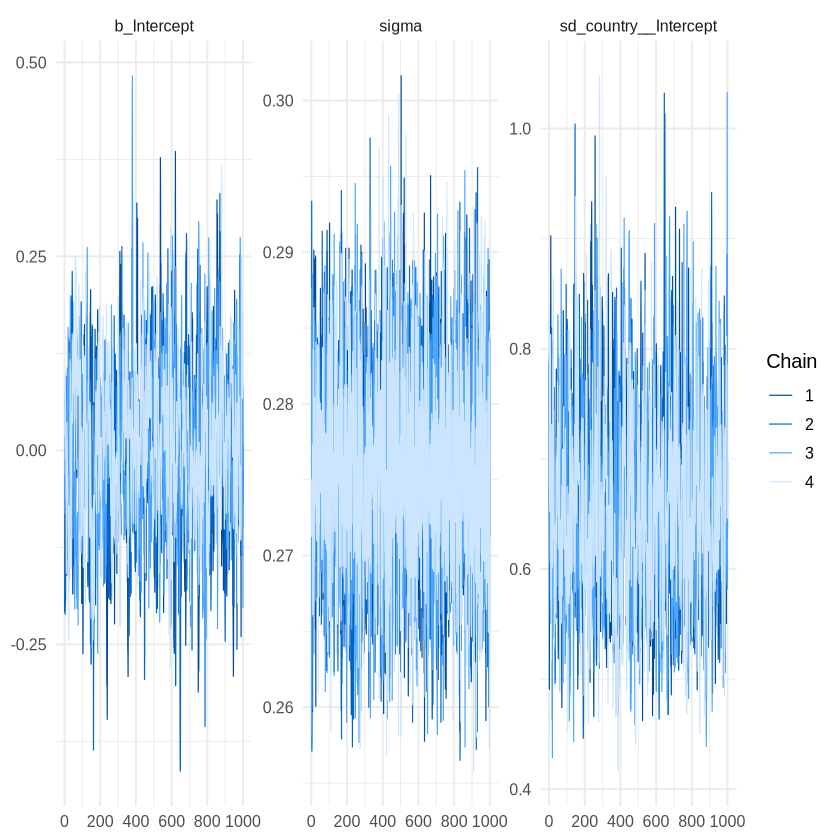

In [15]:
# Trace plots for key parameters
mcmc_trace(fit, pars = c("b_Intercept", "sigma", "sd_country__Intercept"))

## LOO Cross-Validation

In [16]:
# Compute LOO-CV
loo_fit <- loo(fit, save_psis = TRUE)
print(loo_fit)

# Log LOO diagnostics
log_and_print("\nLOO Cross-Validation:")
log_and_print("  ELPD: %.2f (SE: %.2f)", 
              loo_fit$estimates["elpd_loo", "Estimate"], 
              loo_fit$estimates["elpd_loo", "SE"])
log_and_print("  p_loo: %.2f", loo_fit$estimates["p_loo", "Estimate"])

Warning message:
“Found 1 observations with a pareto_k > 0.7 in model 'fit'. We recommend to set 'moment_match = TRUE' in order to perform moment matching for problematic observations. ”



Computed from 4000 by 888 log-likelihood matrix.

         Estimate   SE
elpd_loo   -143.9 32.7
p_loo        55.4  5.1
looic       287.8 65.3
------
MCSE of elpd_loo is NA.
MCSE and ESS estimates assume MCMC draws (r_eff in [0.4, 1.4]).

Pareto k diagnostic values:
                         Count Pct.    Min. ESS
(-Inf, 0.7]   (good)     887   99.9%   653     
   (0.7, 1]   (bad)        1    0.1%   <NA>    
   (1, Inf)   (very bad)   0    0.0%   <NA>    
See help('pareto-k-diagnostic') for details.

LOO Cross-Validation: 
  ELPD: -143.92 (SE: 32.66) 
  p_loo: 55.40 



Pareto k diagnostics: 
  Max k: 0.773 
  Mean k: 0.088 
  k > 0.7: 1 (0.1%) 


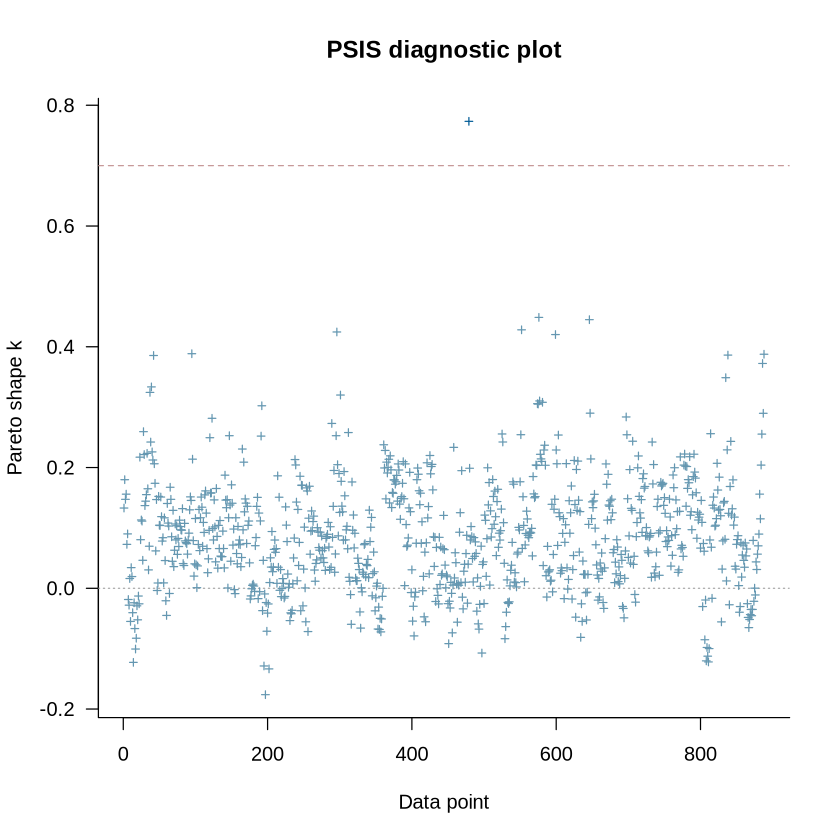

In [17]:
# Check Pareto k values
pareto_k <- loo_fit$diagnostics$pareto_k

log_and_print("\nPareto k diagnostics:")
log_and_print("  Max k: %.3f", max(pareto_k))
log_and_print("  Mean k: %.3f", mean(pareto_k))
log_and_print("  k > 0.7: %d (%.1f%%)", 
              sum(pareto_k > 0.7), 100 * mean(pareto_k > 0.7))

# Plot Pareto k values
plot(loo_fit)

## Posterior Predictive Check

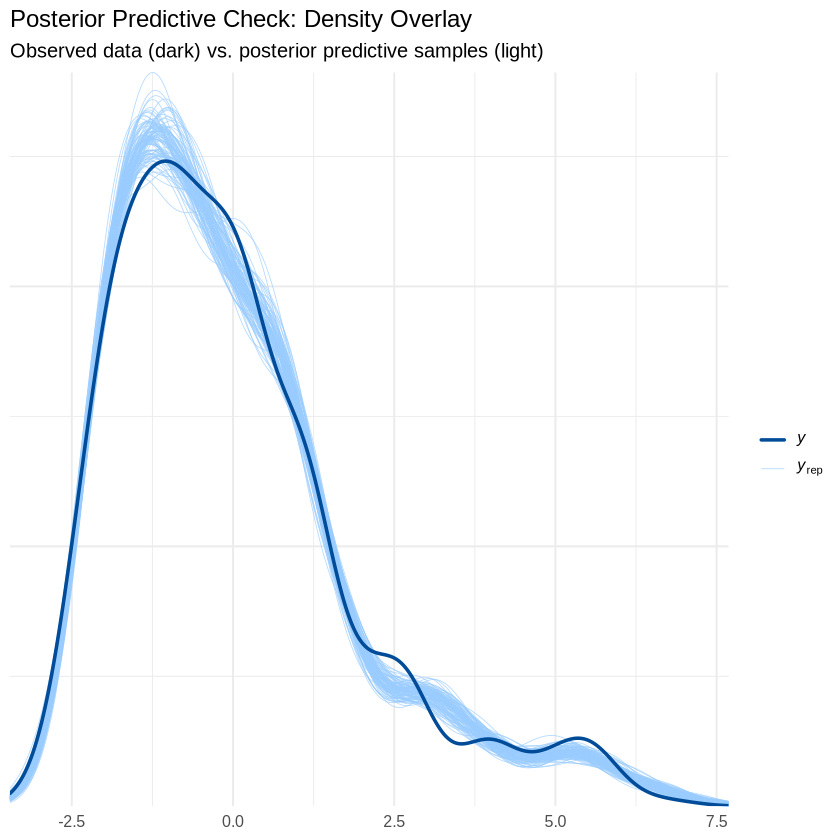

In [18]:
# Posterior predictive check (quick example, not exhaustive)
# Density overlay: Compare the distribution of observed data to posterior predictive samples
# Good fit: Observed data (dark line) should fall within the range of predictive samples (light lines)
suppressWarnings({
  pp_check(fit, ndraws = 100) +
    labs(title = "Posterior Predictive Check: Density Overlay",
         subtitle = "Observed data (dark) vs. posterior predictive samples (light)")
})

# Results

## Fixed Effects (Predictor Coefficients)

Because predictors are standardized, coefficients represent expected changes in the centered life expectancy gap associated with a one-SD change in the predictor, conditional on country.



Table: Fixed Effects (Predictor Coefficients)

|term                    | Estimate| Est.Error|   Q2.5|  Q97.5|
|:-----------------------|--------:|---------:|------:|------:|
|Gap_RoadTraffic         |    0.446|     0.026|  0.396|  0.496|
|Gap_Homicide            |    0.441|     0.024|  0.394|  0.488|
|Gap_Suicide             |    0.365|     0.041|  0.285|  0.446|
|Gap_Neoplasms           |    0.314|     0.054|  0.206|  0.418|
|Gap_ChronicRespiratory  |    0.296|     0.038|  0.222|  0.374|
|Gap_LiverDisease        |    0.250|     0.032|  0.189|  0.311|
|Gap_Cardiovascular      |   -0.188|     0.028| -0.243| -0.133|
|Gap_UnintentionalInjury |    0.161|     0.039|  0.085|  0.238|
|Gap_Alcohol             |    0.138|     0.034|  0.071|  0.204|
|Gap_COVID               |    0.108|     0.010|  0.088|  0.128|
|Gap_Diabetes            |   -0.106|     0.024| -0.154| -0.058|
|Gap_DrugDisorder        |    0.091|     0.020|  0.053|  0.130|

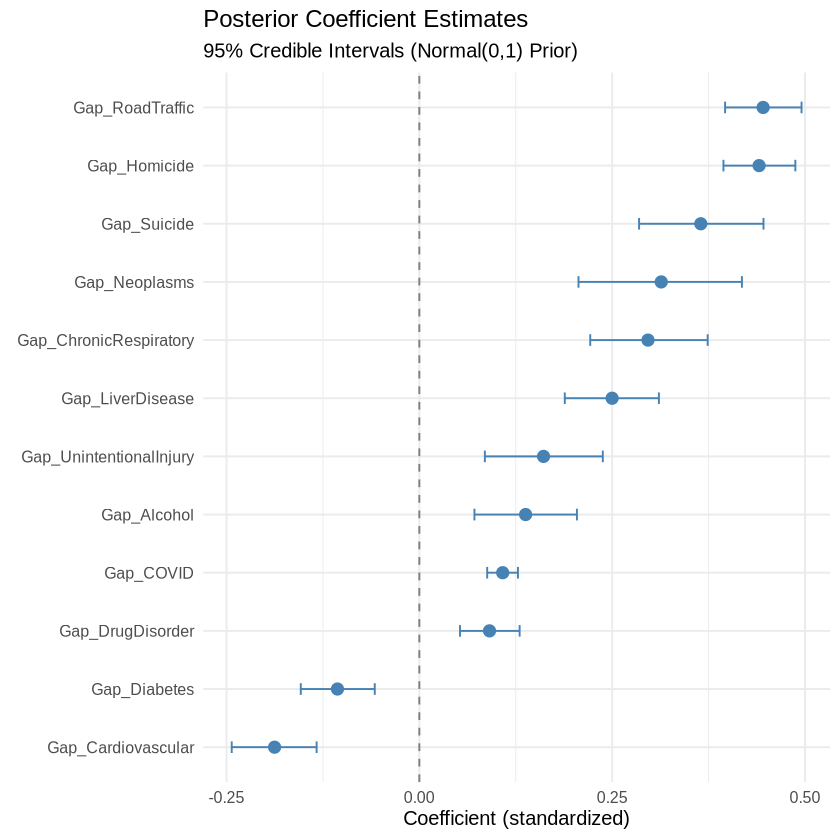

In [19]:
# Extract fixed effects
fixed_eff <- fixef(fit) %>%
  as.data.frame() %>%
  rownames_to_column("term") %>%
  filter(term != "Intercept") %>%
  arrange(desc(abs(Estimate)))

# Plot coefficients with credible intervals
fixed_eff %>%
  ggplot(aes(x = reorder(term, Estimate), y = Estimate)) +
  geom_point(size = 3, color = "steelblue") +
  geom_errorbar(aes(ymin = Q2.5, ymax = Q97.5), width = 0.2, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  coord_flip() +
  labs(
    title = "Posterior Coefficient Estimates",
    subtitle = "95% Credible Intervals (Normal(0,1) Prior)",
    x = NULL,
    y = "Coefficient (standardized)"
  )

# Table
fixed_eff %>%
  knitr::kable(digits = 3, caption = "Fixed Effects (Predictor Coefficients)")

## Random Effects (Country Intercepts)



Table: Country Random Effects

|country | Estimate|   Q2.5|  Q97.5|
|:-------|--------:|------:|------:|
|EST     |    1.322|  0.946|  1.714|
|LVA     |    1.268|  0.909|  1.649|
|KOR     |    1.170|  0.917|  1.429|
|FRA     |    0.852|  0.595|  1.127|
|POL     |    0.779|  0.502|  1.068|
|SVK     |    0.713|  0.440|  0.994|
|LTU     |    0.695|  0.259|  1.135|
|JPN     |    0.635|  0.324|  0.951|
|FIN     |    0.475|  0.174|  0.760|
|IRL     |    0.424|  0.147|  0.686|
|ISL     |    0.401|  0.110|  0.675|
|CAN     |    0.104| -0.155|  0.357|
|DNK     |    0.097| -0.184|  0.373|
|CZE     |    0.019| -0.220|  0.262|
|ISR     |   -0.005| -0.296|  0.266|
|GBR     |   -0.013| -0.277|  0.233|
|USA     |   -0.033| -0.314|  0.247|
|NOR     |   -0.052| -0.306|  0.206|
|SWE     |   -0.145| -0.406|  0.105|
|GRC     |   -0.165| -0.500|  0.183|
|HUN     |   -0.196| -0.522|  0.123|
|AUS     |   -0.205| -0.447|  0.035|
|NZL     |   -0.225| -0.483|  0.025|
|CHE     |   -0.262| -0.499| -0.025|
|COL 

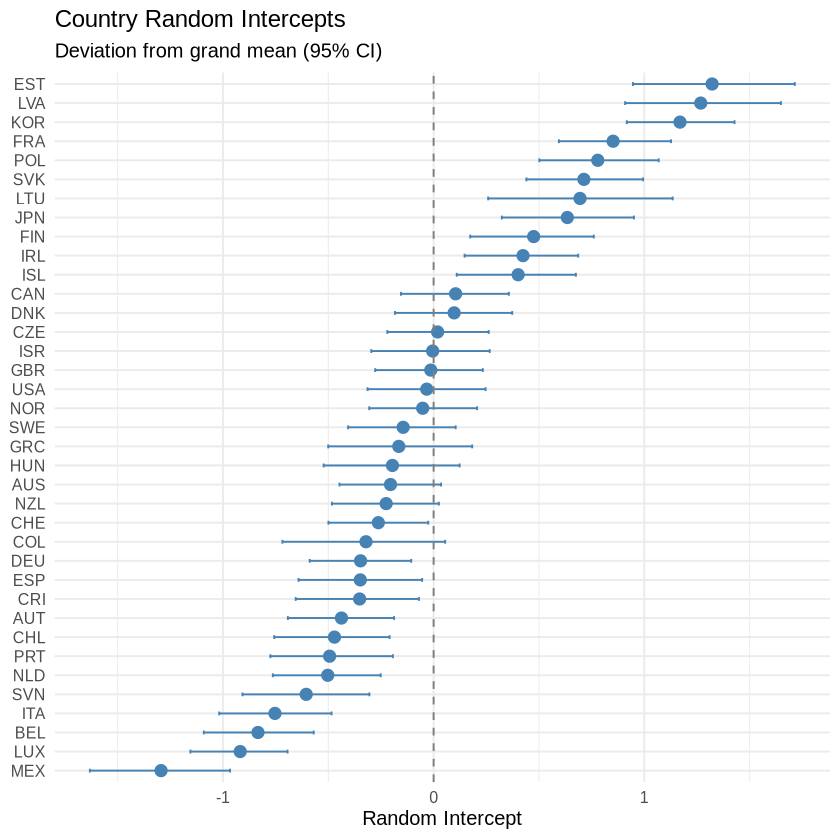

In [20]:
# Extract country random effects
country_effects <- ranef(fit)$country %>%
  as.data.frame() %>%
  rownames_to_column("country") %>%
  arrange(desc(Estimate.Intercept))

# Plot country intercepts
country_effects %>%
  ggplot(aes(x = reorder(country, Estimate.Intercept), y = Estimate.Intercept)) +
  geom_point(size = 3, color = "steelblue") +
  geom_errorbar(aes(ymin = Q2.5.Intercept, ymax = Q97.5.Intercept), 
                width = 0.2, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  coord_flip() +
  labs(
    title = "Country Random Intercepts",
    subtitle = "Deviation from grand mean (95% CI)",
    x = NULL,
    y = "Random Intercept"
  )

# Table
country_effects %>%
  select(country, Estimate = Estimate.Intercept, 
         Q2.5 = Q2.5.Intercept, Q97.5 = Q97.5.Intercept) %>%
  knitr::kable(digits = 3, caption = "Country Random Effects")

## Feature Importance

A heuristic ranking derived from the fitted linear predictor.

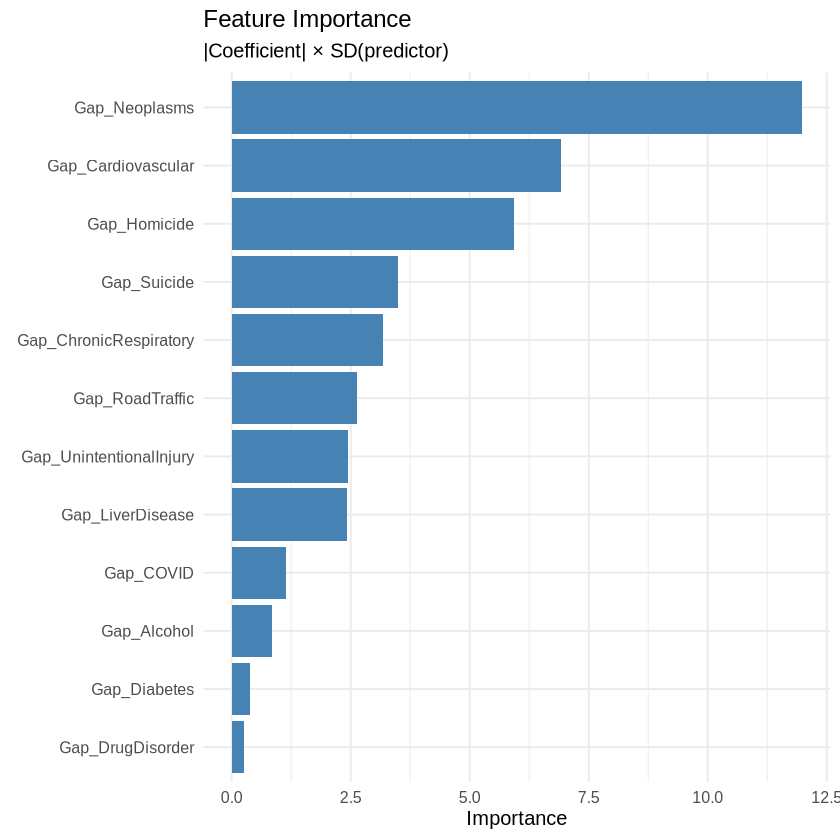

In [21]:
# Compute importance as |coefficient| × SD of predictor
# IMPORTANT: Use original (unstandardized) SDs, not SDs of standardized predictors
# The standardized predictors have SD ≈ 1, which would give incorrect importance
# We stored the original SDs in X_std_safe during preprocessing
predictor_sds <- tibble(
  term = gap_cols,
  sd = X_std_safe  # Original SDs (before standardization)
)

importance <- fixed_eff %>%
  left_join(predictor_sds, by = "term") %>%
  mutate(
    importance = abs(Estimate) * sd,
    importance_lower = abs(Q2.5) * sd,
    importance_upper = abs(Q97.5) * sd
  ) %>%
  arrange(desc(importance))

# Plot importance
importance %>%
  head(12) %>%
  ggplot(aes(x = reorder(term, importance), y = importance)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Feature Importance",
    subtitle = "|Coefficient| × SD(predictor)",
    x = NULL,
    y = "Importance"
  )

## R² and Model Fit

In [22]:
# Bayesian R²
# IMPORTANT: In hierarchical models, there are two types of R²:
# - Conditional R²: includes random effects (country intercepts) in μ
# - Marginal R²: uses only fixed effects (population-level), no random intercepts
#
# brms's bayes_R2() by default computes CONDITIONAL R² (includes random effects)
# Use re_formula = NA to get MARGINAL R²

# Conditional R² (default - includes country random effects)
r2_cond <- bayes_R2(fit, summary = FALSE)
log_and_print("CONDITIONAL R² (includes country random effects):")
log_and_print("  R² (mean): %.3f", mean(r2_cond))
log_and_print("  R² (95%% CI: %.3f - %.3f)",
              quantile(r2_cond, 0.025), quantile(r2_cond, 0.975))

# Marginal R² (fixed effects only, no country intercepts)
r2_marg <- bayes_R2(fit, summary = FALSE, re_formula = NA)
log_and_print("\nMARGINAL R² (fixed effects only, no country intercepts):")
log_and_print("  R² (mean): %.3f", mean(r2_marg))
log_and_print("  R² (95%% CI: %.3f - %.3f)",
              quantile(r2_marg, 0.025), quantile(r2_marg, 0.975))

CONDITIONAL R² (includes country random effects): 
  R² (mean): 0.978 
  R² (95% CI: 0.978 - 0.979) 

MARGINAL R² (fixed effects only, no country intercepts): 
  R² (mean): 0.845 
  R² (95% CI: 0.802 - 0.877) 


# Model Scope and Limitations

- **Linear additive effects**: The model assumes linear relationships between predictors and outcome, with no interaction terms or non-linear transformations.
- **No explicit temporal correlation**: While the model includes country-level random intercepts that capture persistent country differences, it does not explicitly model temporal autocorrelation or year-to-year dependencies.
- **Sensitivity to prior scale not explored here**: The analysis uses standard weakly informative priors; a full sensitivity analysis would explore how results change under alternative prior specifications.

The model supports predictive counterfactuals, but all results represent associations, not causal effects.

# Save Results

The following section saves all model outputs and preprocessing parameters to enable cross-language validation against the PyMC implementation.

In [23]:
# Create output directories if needed
dir.create("../data", showWarnings = FALSE, recursive = TRUE)
dir.create("../output/tables", showWarnings = FALSE, recursive = TRUE)

# Save model fit (RDS format - can be read by Python using pyreadr or rpy2)
saveRDS(fit, "../data/bayesian_model_brms_fit.rds")

# Save summary statistics (for quick reference)
write_csv(fixed_eff, "../output/tables/beta_coefficients_le_brms.csv")
write_csv(country_effects, "../output/tables/alpha_coefficients_le_brms.csv")
write_csv(importance, "../output/tables/importance_measures_le_brms.csv")

# Extract and save FULL posterior samples for Python comparison
# Convert to draws_df format (flattens chains × draws into single column)
draws_df <- as_draws_df(fit)

# Extract predictor coefficients (beta)
beta_samples <- draws_df %>%
  select(starts_with("b_"), -b_Intercept) %>%
  rename_with(~ str_remove(.x, "^b_"), everything())

# Get predictor names (remove "b_" prefix)
beta_cols <- names(beta_samples)
log_and_print("\nExtracting posterior samples:")
log_and_print("  Beta coefficients: %d predictors, %d draws", 
              length(beta_cols), nrow(beta_samples))

# Save beta samples (predictor coefficients)
write_csv(beta_samples, "../data/beta_samples_brms.csv")
log_and_print("  ✓ Saved: ../data/beta_samples_brms.csv")

# Extract country intercepts (alpha)
# brms stores as r_country[country,Intercept], we need to pivot
alpha_samples_wide <- draws_df %>%
  select(starts_with("r_country["))

# Get country names from column names
alpha_cols <- names(alpha_samples_wide)
country_names <- str_extract(alpha_cols, "(?<=\\[)[^,]+(?=,)") %>% unique() %>% sort()

# Pivot to long format: draw, country, value
alpha_samples <- alpha_samples_wide %>%
  mutate(draw = row_number()) %>%
  pivot_longer(cols = -draw, names_to = "country_full", values_to = "alpha") %>%
  mutate(country = str_extract(country_full, "(?<=\\[)[^,]+(?=,)")) %>%
  select(draw, country, alpha) %>%
  pivot_wider(names_from = country, values_from = alpha) %>%
  select(-draw)

# Reorder columns to match country order
alpha_samples <- alpha_samples[, country_names]

log_and_print("  Country intercepts: %d countries, %d draws", 
              ncol(alpha_samples), nrow(alpha_samples))
write_csv(alpha_samples, "../data/alpha_samples_brms.csv")
log_and_print("  ✓ Saved: ../data/alpha_samples_brms.csv")

# Extract hyperparameters and residual SD
hyperparams <- draws_df %>%
  select(
    mu_alpha = b_Intercept,           # Grand mean 
    sigma_alpha = sd_country__Intercept,  # Random effect SD 
    sigma = sigma                      # Residual SD 
  )

log_and_print("  Hyperparameters: %d draws", nrow(hyperparams))
write_csv(hyperparams, "../data/hyperparams_brms.csv")
log_and_print("  ✓ Saved: ../data/hyperparams_brms.csv")

# Save preprocessing parameters as JSON (for Python to read)
preprocessing_json <- list(
  X_mean = as.list(setNames(X_mean, gap_cols)),
  X_std = as.list(setNames(X_std_safe, gap_cols)),
  y_mean = y_mean,
  predictors = gap_cols,
  n_observations = nrow(model_data),
  n_countries = length(unique(model_data$country)),
  n_years = length(unique(model_data$Year)),
  sampling_params = list(
    chains = 4,
    iter = 3000,
    warmup = 2000,
    draws_per_chain = 1000,
    total_draws = 4000
  )
)

write_json(preprocessing_json, "../data/preprocessing_params_brms.json", pretty = TRUE)
log_and_print("  ✓ Saved: ../data/preprocessing_params_brms.json")

log_and_print("\n✓ All results saved:")
log_and_print("  Summary tables: ../output/tables/")
log_and_print("  Full posterior samples: ../data/*_samples_brms.csv")
log_and_print("  Preprocessing params: ../data/preprocessing_params_brms.json")
log_and_print("  Model fit (RDS): ../data/bayesian_model_brms_fit.rds")
log_and_print("\nNote: CSV files can be read directly by Python pandas.")
log_and_print("      RDS file can be read using pyreadr or rpy2.")

Warning message:
“Dropping 'draws_df' class as required metadata was removed.”



Extracting posterior samples: 
  Beta coefficients: 12 predictors, 4000 draws 
  ✓ Saved: ../data/beta_samples_brms.csv 


Warning message:
“Dropping 'draws_df' class as required metadata was removed.”


  Country intercepts: 37 countries, 4000 draws 
  ✓ Saved: ../data/alpha_samples_brms.csv 


Warning message:
“Dropping 'draws_df' class as required metadata was removed.”


  Hyperparameters: 4000 draws 
  ✓ Saved: ../data/hyperparams_brms.csv 
  ✓ Saved: ../data/preprocessing_params_brms.json 

✓ All results saved: 
  Summary tables: ../output/tables/ 
  Full posterior samples: ../data/*_samples_brms.csv 
  Preprocessing params: ../data/preprocessing_params_brms.json 
  Model fit (RDS): ../data/bayesian_model_brms_fit.rds 

Note: CSV files can be read directly by Python pandas. 
      RDS file can be read using pyreadr or rpy2. 


# Session Info

In [24]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Linux Mint 20.3

Matrix products: default
BLAS/LAPACK: /home/downey/miniconda3/envs/LifeExpectancy/lib/libmkl_rt.so.2;  LAPACK version 3.12.1

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] jsonlite_2.0.0   patchwork_1.3.2  posterior_1.6.1  tidybayes_3.0.7 
 [5] loo_2.9.0        bayesplot_1.15.0 brms_2.23.0      Rcpp_1.1.1      
 [9] lubridate_1.9.4  forcats_1.0.1    stringr_1.6.0    dplyr_1.1.4     
[13] purrr_1.2.

# Cleanup

In [25]:
# Close log file
close_log_file()

Log file closed.
